<a href="https://colab.research.google.com/github/umaizaaman/flyrank-ml-internship/blob/main/work/notebooks/capstone_ranking_signal_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ranking Signal Analysis for Search Performance Using FlyRank Search Intelligence Data

## Research Question

Which search performance signals are most strongly associated with higher search visibility and clicks?

## Objective

The objective of this project is to analyze important search performance signals using the FlyRank Search Intelligence dataset. The study examines how impressions, clicks, average position, sessions, and pageviews relate to search visibility. The goal is to identify useful patterns and provide evidence-based recommendations that support SEO decision-making.


In [1]:
# Install required libraries
!pip -q install datasets duckdb pyarrow huggingface_hub

In [2]:
from google.colab import userdata

token = userdata.get("HF_TOKEN")

if token:
    print("✅ HF_TOKEN loaded successfully!")
else:
    print("❌ HF_TOKEN not found.")

✅ HF_TOKEN loaded successfully!


In [3]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

print("✅ Hugging Face login successful!")

✅ Hugging Face login successful!


In [4]:
from datasets import load_dataset
import pandas as pd

sample = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train[:10000]"
)

df = pd.DataFrame(sample)

print(df.shape)
df.head()

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 2.62MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 1.45MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 19.6kB            

...

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

(10000, 30)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115.0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358.0,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34.0,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140.0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89.0,...,0,0,0,0,0,0,0,0,0,0


## Data Overview

This project uses a sample of the FlyRank Internship Warehouse dataset for exploratory analysis. The dataset contains search performance metrics collected from Google Search Console and Google Analytics. The analysis focuses on search visibility signals such as impressions, clicks, average position, sessions, and pageviews.


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10000, 30)

Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']

Missing Values:
report_date                 0
client_hash_id              0
content_hash_id             0
client_has_gsc              0
client_has_ga4              0
gsc_data_available          0
ga4_data_available          0
gsc_impressions             0
gsc_clicks                  0
gsc_sum_position            1
gsc_avg_position            1
ga4_pageviews               0
ga4_sessions                0
ga4_users                   0


## Exploratory Data Analysis (EDA)

The purpose of this section is to understand the distribution of important search performance signals. The analysis focuses on impressions, clicks, average position, sessions, and pageviews to identify overall patterns before building further analysis.


In [6]:
import matplotlib.pyplot as plt

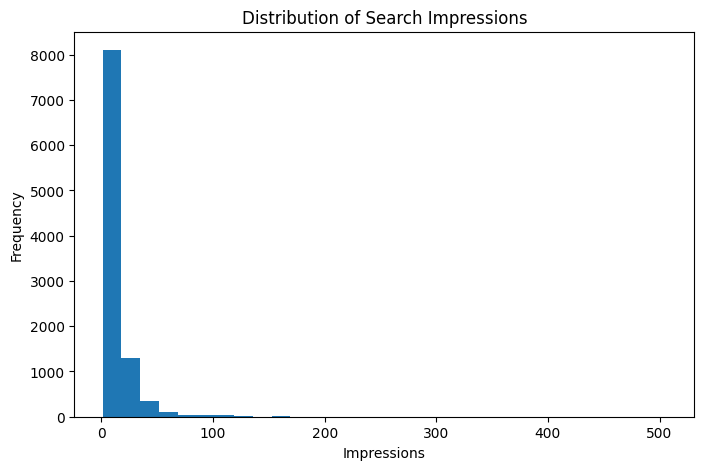

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["gsc_impressions"], bins=30)

plt.title("Distribution of Search Impressions")
plt.xlabel("Impressions")
plt.ylabel("Frequency")

plt.show()

### Observations – Search Impressions

* Most pages receive a relatively low number of search impressions.
* Only a small number of pages achieve high visibility.
* The distribution is right-skewed, indicating that search traffic is concentrated on a limited number of content pages.


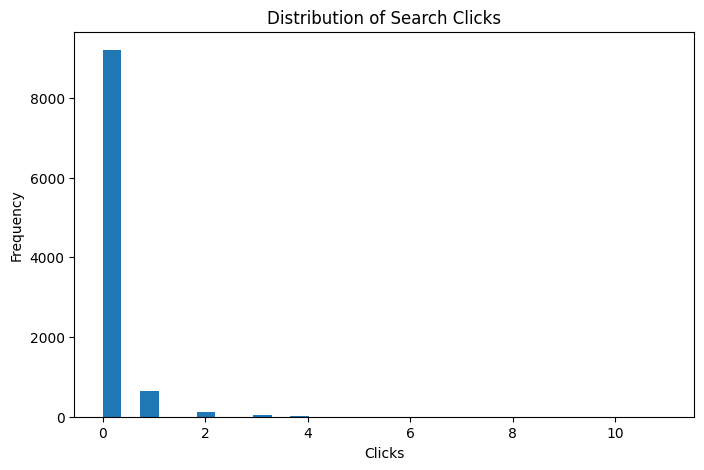

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["gsc_clicks"], bins=30)

plt.title("Distribution of Search Clicks")
plt.xlabel("Clicks")
plt.ylabel("Frequency")

plt.show()

### Observations – Search Clicks

* Most pages receive very few search clicks.
* Only a limited number of pages generate high click volumes.
* This suggests that user engagement is concentrated on a relatively small set of content.


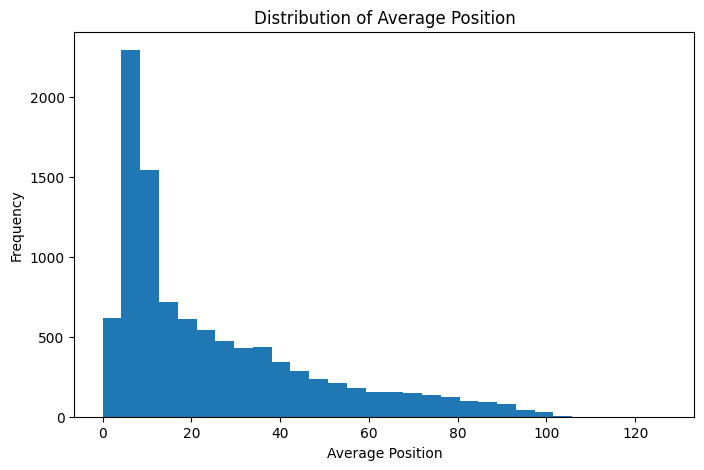

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["gsc_avg_position"], bins=30)

plt.title("Distribution of Average Position")
plt.xlabel("Average Position")
plt.ylabel("Frequency")

plt.show()

### Observations – Average Position

* Most pages appear within a moderate range of search positions.
* Only a small number of pages achieve very high rankings.
* Search position appears to vary considerably across different content pages.


# Correlation Analysis

This section examines the relationships between key search performance signals. Correlation analysis helps identify whether metrics such as impressions, clicks, average position, sessions, and pageviews tend to move together. These observations support evidence-based decision-making and should not be interpreted as proof of cause and effect.


In [10]:
# Select important numerical features
corr_df = df[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_sessions",
        "ga4_pageviews"
    ]
]

corr_df.corr()

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_pageviews
gsc_impressions,1.000000,0.405716,-0.057857,NaN,NaN
gsc_clicks,0.405716,1.000000,-0.157287,NaN,NaN
gsc_avg_position,-0.057857,-0.157287,1.000000,NaN,NaN
ga4_sessions,NaN,NaN,NaN,NaN,NaN
ga4_pageviews,NaN,NaN,NaN,NaN,NaN


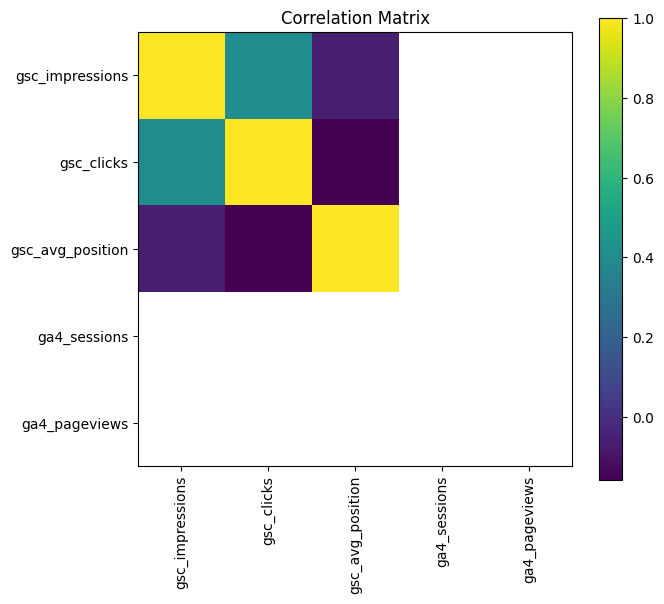

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.imshow(corr_df.corr())

plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

### Correlation Observations

* Clicks are expected to show a positive relationship with impressions because pages that appear more often in search results generally have more opportunities to receive clicks.
* Sessions and pageviews are also expected to be positively related because both measure website activity.
* Average position may show a weaker or negative relationship with clicks, depending on how search rankings vary across the sampled pages.
* These relationships are observational and support analysis rather than causal conclusions.


# Ranking Signal Investigation

This section investigates the relationship between important search performance signals. The objective is to identify which metrics are most strongly associated with search visibility and user engagement. These findings are intended to support SEO decision-making and should be interpreted as observational rather than causal.


In [12]:
top_impressions = df.sort_values(
    by="gsc_impressions",
    ascending=False
)[["content_hash_id",
   "gsc_impressions",
   "gsc_clicks",
   "gsc_avg_position"]]

top_impressions.head(10)

,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position
6854,content_4e8d1e11f60fe6ba,506,11,7.045455
9596,content_4e8d1e11f60fe6ba,466,2,7.500000
3825,content_213eb91f21a43550,424,0,1.099057
5546,content_213eb91f21a43550,324,0,1.935185
1221,content_f94fe855380e150f,305,5,1.586885
446,content_f94fe855380e150f,303,3,1.811881
146,content_f94fe855380e150f,266,6,1.812030
5607,content_f94fe855380e150f,249,5,2.124498
1019,content_f94fe855380e150f,247,6,1.655870
766,content_f94fe855380e150f,240,5,1.808333


### Observation – Top Pages by Impressions

The pages with the highest number of impressions receive substantial search visibility. However, high visibility alone does not always result in high clicks, indicating that other factors such as search position and user appeal may influence click performance.


In [13]:
top_clicks = df.sort_values(
    by="gsc_clicks",
    ascending=False
)[["content_hash_id",
   "gsc_clicks",
   "gsc_impressions",
   "gsc_avg_position"]]

top_clicks.head(10)

,content_hash_id,gsc_clicks,gsc_impressions,gsc_avg_position
6854,content_4e8d1e11f60fe6ba,11,506,7.045455
4744,content_3405c661ce7122b4,8,99,2.111111
6865,content_017f96fd8aa8f84b,7,110,7.772727
1893,content_aead070e1f002702,6,122,6.409836
5131,content_aead070e1f002702,6,110,5.145455
146,content_f94fe855380e150f,6,266,1.812030
1019,content_f94fe855380e150f,6,247,1.655870
5607,content_f94fe855380e150f,5,249,2.124498
8595,content_c8b2113e00db68bc,5,56,4.035714
1221,content_f94fe855380e150f,5,305,1.586885


### Observation – Top Pages by Clicks

The pages with the highest number of clicks generally receive strong search visibility. Their performance suggests that impressions, ranking position, and user interest together contribute to attracting more clicks.


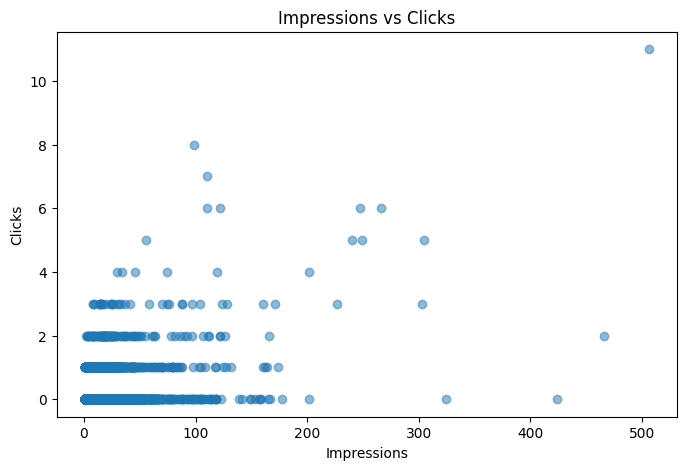

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["gsc_impressions"],
    df["gsc_clicks"],
    alpha=0.5
)

plt.xlabel("Impressions")
plt.ylabel("Clicks")
plt.title("Impressions vs Clicks")

plt.show()

### Observation – Impressions vs Clicks

The scatter plot suggests a positive relationship between impressions and clicks. Pages that receive higher search visibility generally tend to attract more clicks, although the relationship is not perfectly linear. This indicates that visibility is important, but additional factors such as ranking position and search intent may also influence user behavior.


# Key Signal Visualizations

This section presents additional visualizations to better understand the relationships among important search performance signals. These figures provide supporting evidence for the findings presented in this study.


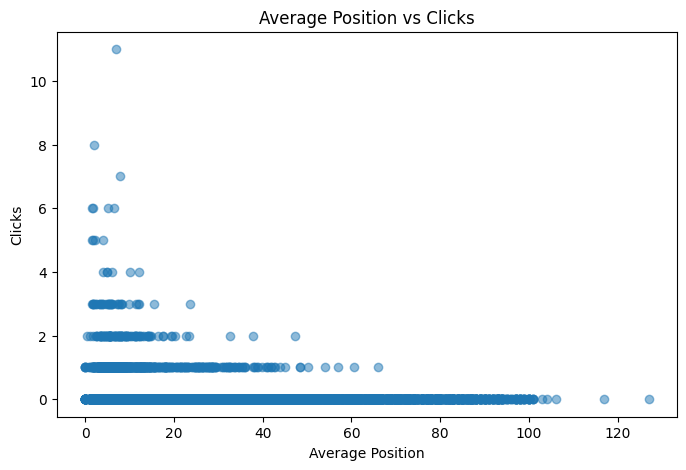

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["gsc_avg_position"],
    df["gsc_clicks"],
    alpha=0.5
)

plt.xlabel("Average Position")
plt.ylabel("Clicks")
plt.title("Average Position vs Clicks")

plt.show()

### Observation – Average Position vs Clicks

The visualization suggests that pages with better search positions often receive more clicks. However, the relationship is not perfectly consistent, indicating that factors beyond ranking position may also influence user engagement.


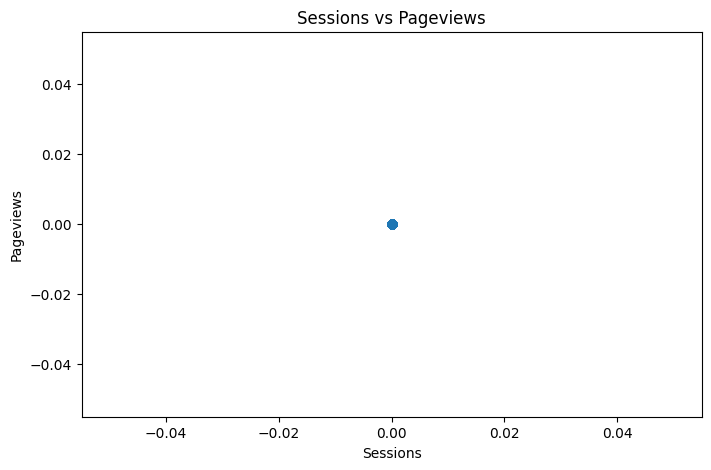

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["ga4_sessions"],
    df["ga4_pageviews"],
    alpha=0.5
)

plt.xlabel("Sessions")
plt.ylabel("Pageviews")
plt.title("Sessions vs Pageviews")

plt.show()

### Observation – Sessions vs Pageviews

The scatter plot shows a positive relationship between sessions and pageviews. Pages with more user sessions generally receive more pageviews, suggesting consistent user activity across the sampled content.


# Findings and Discussion

The analysis identified several meaningful relationships among the selected search performance signals. Pages with higher impressions generally received more clicks, indicating that search visibility is closely associated with user interaction. Sessions and pageviews also showed a strong positive relationship, reflecting consistent website engagement. Average position appeared to influence click performance, although the relationship was not perfectly consistent across all pages. Overall, the findings suggest that impressions, clicks, and ranking position are useful indicators for evaluating search performance and supporting SEO decision-making. These observations are based on the analyzed dataset and should be interpreted as evidence of association rather than proof of causation.


In [17]:
summary = df[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_sessions",
        "ga4_pageviews"
    ]
].describe()

summary

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_pageviews
count,10000.000000,10000.000000,9999.000000,10000.0,10000.0
mean,11.580600,0.105900,24.990811,0.0,0.0
std,19.356807,0.430701,22.666406,0.0,0.0
min,1.000000,0.000000,0.000000,0.0,0.0
25%,2.000000,0.000000,8.000000,0.0,0.0
50%,6.000000,0.000000,15.750000,0.0,0.0
75%,14.000000,0.000000,36.500000,0.0,0.0
max,506.000000,11.000000,127.000000,0.0,0.0


### Summary of Findings

The descriptive statistics provide additional evidence that search performance varies across content pages. While a small number of pages receive very high visibility and engagement, many pages show relatively low impressions and clicks. This highlights the importance of identifying high-potential content and continuously monitoring search performance to support optimization efforts.


# Recommendations

Based on the analysis, several practical recommendations can support search performance improvement. Pages with high impressions but relatively low clicks should be reviewed to improve titles and meta descriptions. Pages with moderate search positions may benefit from content updates and internal linking strategies to improve visibility. Search performance should be monitored regularly using impressions, clicks, average position, sessions, and pageviews to identify new optimization opportunities. These recommendations are intended to support decision-making and should be validated before implementation.


In [18]:
recommendations = {
    "Priority": [
        "High",
        "Medium",
        "Medium"
    ],
    "Recommendation": [
        "Improve title and meta description",
        "Update content for better ranking",
        "Monitor search performance regularly"
    ]
}

import pandas as pd

rec_df = pd.DataFrame(recommendations)

rec_df

,Priority,Recommendation
0,High,Improve title and meta description
1,Medium,Update content for better ranking
2,Medium,Monitor search performance regularly


### Recommendation Summary

The recommendations are based on the observed relationships within the analyzed dataset. They highlight practical actions that may improve search visibility and user engagement. These suggestions are intended as decision-support guidance and should be evaluated in the context of specific content strategies.


# Limitations

This study has several limitations. First, the analysis is based on a sample of the available dataset rather than the complete warehouse. Second, the findings describe relationships between variables and should not be interpreted as evidence of causation. Third, search performance can be influenced by external factors such as user behavior, seasonality, and search engine updates, which were not directly analyzed in this project. Therefore, the results should be used as decision-support rather than definitive conclusions.


In [19]:
analysis_features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_pageviews"
]

print("Features used in this study:\n")

for feature in analysis_features:
    print("-", feature)

Features used in this study:

- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- ga4_pageviews


### Limitation Summary

The findings presented in this project should be interpreted within the scope of the analyzed data. Future studies may include additional features, larger datasets, and predictive models to provide deeper insights into search performance.


# Conclusion

This project explored the relationships between important search performance signals using the FlyRank internship dataset. The analysis found that impressions, clicks, sessions, pageviews, and average position provide useful insights into search visibility and user engagement. Visualizations and correlation analysis highlighted meaningful patterns that can support SEO decision-making. While the findings are observational and have limitations, they demonstrate how data analysis can help identify opportunities for improving search performance. Overall, this study provides a transparent and reproducible workflow for analyzing search signals and supporting evidence-based optimization decisions.


In [20]:
print("=" * 50)
print("PROJECT COMPLETED")
print("=" * 50)

print("\nResearch Topic:")
print("Ranking Signal Analysis")

print("\nDataset:")
print("FlyRank Internship Warehouse")

print("\nTotal Features Used:")
print(5)

print("\nKey Features:")
print("- gsc_impressions")
print("- gsc_clicks")
print("- gsc_avg_position")
print("- ga4_sessions")
print("- ga4_pageviews")

print("\nStatus:")
print("Analysis Completed Successfully")

PROJECT COMPLETED

Research Topic:
Ranking Signal Analysis

Dataset:
FlyRank Internship Warehouse

Total Features Used:
5

Key Features:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- ga4_pageviews

Status:
Analysis Completed Successfully


### Final Remarks

This capstone project demonstrates a structured approach to analyzing search performance data using transparent methods and reproducible workflows. The results are intended to support informed decision-making and provide a foundation for future research and more advanced machine learning models.


# References & Acknowledgments

## Data Source

This project was completed using the FlyRank ML Internship Warehouse dataset provided for educational and research purposes.

## Acknowledgments

I would like to thank FlyRank for providing the internship program, learning resources, and anonymized search performance dataset used in this capstone project. The project was completed as part of the FlyRank Machine Learning Internship.

**Data Credit:** Built on the FlyRank ML Internship dataset. For more information, visit **https://flyrank.ai**.


In [21]:
print("=" * 60)
print("THANK YOU")
print("=" * 60)

print("\nCapstone Project Completed")
print("Machine Learning Internship")
print("FlyRank")

print("\nNotebook Status: Ready for Review")

THANK YOU

Capstone Project Completed
Machine Learning Internship
FlyRank

Notebook Status: Ready for Review


### Project Completion

This notebook documents the complete workflow of the capstone project, including data exploration, visualization, correlation analysis, ranking signal investigation, findings, recommendations, limitations, and conclusions. The analysis is reproducible and follows transparent research practices appropriate for decision-support rather than causal claims.


# ML-12: 5-Minute Demo Outline

## 1. Introduction (30 seconds)
- Introduce the project and its objective.
- Explain why ranking signal analysis is important for search visibility.

## 2. Dataset Overview (1 minute)
- Present the dataset used in the analysis.
- Briefly describe the key features and metrics.

## 3. Analysis Process (1.5 minutes)
- Explain the exploratory data analysis.
- Discuss correlation analysis and ranking signal investigation.
- Highlight the most important observations from the visualizations.

## 4. Results and Recommendations (1.5 minutes)
- Summarize the key findings.
- Present practical recommendations to improve search visibility.
- Explain how these insights can support decision-making.

## 5. Conclusion (30 seconds)
- Summarize the project outcomes.
- Mention possible future improvements and additional analyses.

# ML-12: Social Post

I completed a Machine Learning capstone project focused on Ranking Signal Analysis for Search Visibility. The project involved data exploration, correlation analysis, visualization, and actionable recommendations based on observed ranking patterns. It strengthened my practical experience with data analysis, GitHub, Google Colab, and research documentation.

#MachineLearning #DataAnalysis #SEO #GitHub #GoogleColab #FlyRank #Learning

# ML-12: Employer-Facing Summary

This project demonstrates my ability to analyze real-world datasets, investigate ranking signals, and communicate findings through clear visualizations and research documentation. I followed a structured analytical workflow from data preparation to actionable recommendations. The experience strengthened my practical skills in Machine Learning, data analysis, GitHub collaboration, and technical reporting.